# 3.0 — Exploration des données enrichies

| | |
|---|---|
| **Auteur** | Alexandre Gire |
| **Date** | 01/10/2026 |
| **Contexte** | Action issue du point d'étape P2 : « Nouvelle exploration notebooks avec les données enrichies » |
| **Suite de** | `1.0-mr-initial-data-exploration` (Telco seul) · `2.0-census-geo-enrichment-test` (API Census) |

## Résumé

L'exploration montre que **les trois sources d'enrichissement ne sont pas exploitables en l'état pour la modélisation** :

| Source | Constat principal | Preuve |
|---|---|---|
| **Satisfaction** | Générée à partir de la cible `Churn` → **fuite de cible** | `nps_score <= 0` prédit le churn à 99,4 % ; ROC-AUC 0,845 → 1,000 |
| **Feedback (LLM)** | Le prompt de génération contenait `Churn: Yes/No` → **fuite de cible** | 97 % des verbatims de churners évoquent un départ ; ROC-AUC 0,832 → 0,926 avec le seul sentiment |
| **Géographie (Census)** | Codes postaux attribués d'après `MonthlyCharges` → **information redondante** | ROC-AUC inchangée (0,845 avec ou sans) |

La base Telco est saine ; les règles de nettoyage Silver et les **décisions à prendre en binôme** sont détaillées en [section 8](#8.-Synthèse-et-recommandations).

## Sommaire
1. Chargement des sources
2. Qualité et cohérence entre sources
3. Enrichissement géographique (US Census)
4. Satisfaction et interactions support
5. Verbatims clients (feedback)
6. Jeu de données consolidé
7. Mesure de l'impact : étude d'ablation
8. Synthèse et recommandations

## Sources

| Source | Fichier | Entité MCD | Origine |
|---|---|---|---|
| Base clients | `telco.csv` | CLIENT, CONTRAT, SERVICES | Kaggle Telco + `zipcode` simulé |
| Satisfaction / support | `telco_satisfaction.csv` | SATISFACTION | Synthétique |
| Verbatims clients | `telco_noisy_feedback_prep.csv` | FEEDBACK | Généré par LLM, bruité |
| Verbatims complets | `telco_prep.csv`, `telco_churn_with_all_feedback.csv` | — (étapes intermédiaires) | Généré par LLM |
| Indicateurs géographiques | API US Census (ACS 5-Year 2022 + TIGER/Web) | ZONE_GEO | Open data |

**Prérequis**
- Environnement : `poetry install` (groupe `dev` inclus).
- Données : contenu de `data-enrichi.zip` extrait dans `data/raw/` (données non versionnées).
- Clé API Census dans `.env` à la racine (`cp .env.example .env`). Les données Census sont mises en cache dans `data/processed/` après le premier appel.

## 0. Configuration

In [1]:
import json
import os
import urllib.parse
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from dotenv import load_dotenv
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
load_dotenv(PROJECT_ROOT / ".env")

RANDOM_STATE = 42

# Code couleur commun à tout le notebook : bleu = clients fidèles, orange = churners
COLOR_STAY, COLOR_CHURN, COLOR_NEUTRAL, COLOR_MUTED = "#2a78d6", "#eb6834", "#f0efec", "#52514e"
CHURN_PALETTE = {"Fidèle": COLOR_STAY, "Churn": COLOR_CHURN}
DIVERGING_CMAP = LinearSegmentedColormap.from_list("churn_div", [COLOR_STAY, COLOR_NEUTRAL, COLOR_CHURN])

sns.set_theme(
    style="whitegrid",
    rc={"axes.edgecolor": "#c9c8c3", "grid.color": "#e8e7e3", "axes.titleweight": "bold", "axes.titlesize": 11},
)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

print(f"pandas {pd.__version__} · scikit-learn {sklearn.__version__} · seaborn {sns.__version__}")

pandas 2.3.3 · scikit-learn 1.9.0 · seaborn 0.13.2


In [2]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    # Intensité de l'association entre deux variables catégorielles (0 = aucune, 1 = parfaite)
    table = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(table)[0]
    return float(np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1))))


def evaluate_rule(pred: pd.Series, y: pd.Series) -> dict:
    # Performance d'une règle de décision binaire (True = churn prédit)
    tp = (pred & (y == 1)).sum()
    return {
        "accuracy": (pred == y).mean(),
        "précision": tp / pred.sum() if pred.sum() else np.nan,
        "rappel": tp / (y == 1).sum(),
    }

## 1. Chargement des sources

In [3]:
df_telco = pd.read_csv(DATA_RAW / "telco.csv", dtype={"zipcode": str})
df_satisfaction = pd.read_csv(DATA_RAW / "telco_satisfaction.csv")

# Les fichiers *_prep.csv ont été exportés avec leur index pandas : colonnes d'index à écarter
df_feedback = pd.read_csv(DATA_RAW / "telco_noisy_feedback_prep.csv", index_col=0).drop(columns="Unnamed: 0")
df_feedback_full = pd.read_csv(DATA_RAW / "telco_prep.csv", index_col=0)
df_feedback_raw = pd.read_csv(DATA_RAW / "telco_churn_with_all_feedback.csv")

sources = {
    "telco.csv": df_telco,
    "telco_satisfaction.csv": df_satisfaction,
    "telco_noisy_feedback_prep.csv": df_feedback,
    "telco_prep.csv": df_feedback_full,
    "telco_churn_with_all_feedback.csv": df_feedback_raw,
}

pd.DataFrame(
    [
        {
            "source": name,
            "lignes": len(df),
            "colonnes": df.shape[1],
            "customerID uniques": df["customerID"].nunique(),
            "valeurs manquantes": int(df.isna().sum().sum()),
        }
        for name, df in sources.items()
    ]
).set_index("source")

,lignes,colonnes,customerID uniques,valeurs manquantes
source,,,,
telco.csv,7043,22,7043,0
telco_satisfaction.csv,7043,8,7043,0
telco_noisy_feedback_prep.csv,7032,25,7032,5274
telco_prep.csv,7032,25,7032,0
telco_churn_with_all_feedback.csv,7043,23,7043,0


Toutes les sources partagent la clé `customerID`, sans doublon. Deux volumétries coexistent : **7 043** clients (`telco`, `satisfaction`, feedback brut) et **7 032** (fichiers feedback préparés).
Les 5 274 valeurs manquantes de `telco_noisy_feedback_prep.csv` correspondent aux verbatims volontairement retirés (section 2.3).

## 2. Qualité et cohérence entre sources

### 2.1 Les 11 clients absents des fichiers feedback

In [4]:
# Les fichiers préparés ont passé les identifiants en minuscules : retour au format de telco.csv
df_feedback["customerID"] = df_feedback["customerID"].str.upper()
df_feedback_full["customerID"] = df_feedback_full["customerID"].str.upper()

absents = df_telco[~df_telco["customerID"].isin(df_feedback["customerID"])]
print(f"{len(absents)} clients de telco.csv absents des fichiers feedback")
print(f"Valeurs de TotalCharges pour ces clients : {absents['TotalCharges'].unique().tolist()}")
absents[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

11 clients de telco.csv absents des fichiers feedback
Valeurs de TotalCharges pour ces clients : [' ']


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Ce sont les **11 clients à `tenure = 0`** dont `TotalCharges` vaut `" "` (déjà identifiés dans le notebook `1.0`). Les fichiers feedback les ont retirés en amont : la règle doit être appliquée **une seule fois, en couche Silver**, pour toutes les sources.

### 2.2 Cohérence des valeurs et des formats

In [5]:
check = df_telco.merge(
    df_feedback[["customerID", "Churn", "MonthlyCharges"]],
    on="customerID",
    suffixes=("_telco", "_feedback"),
)
print(
    f"Churn identique          : {((check['Churn_telco'] == 'Yes').astype(int) == check['Churn_feedback']).mean():.1%}"
)
print(f"MonthlyCharges identique : {(check['MonthlyCharges_telco'] == check['MonthlyCharges_feedback']).mean():.1%}")
print()
print("Formats : telco.csv vs telco_noisy_feedback_prep.csv")
pd.concat(
    [
        df_telco[["customerID", "gender", "Contract", "Churn"]].head(3).assign(source="telco"),
        df_feedback[["customerID", "gender", "Contract", "Churn"]].head(3).assign(source="feedback"),
    ]
)

Churn identique          : 100.0%
MonthlyCharges identique : 100.0%

Formats : telco.csv vs telco_noisy_feedback_prep.csv


,customerID,gender,Contract,Churn,source
0,7590-VHVEG,Female,Month-to-month,No,telco
1,5575-GNVDE,Male,One year,No,telco
2,3668-QPYBK,Male,Month-to-month,Yes,telco
0,7590-VHVEG,female,month-to-month,0,feedback
1,5575-GNVDE,male,one year,0,feedback
2,3668-QPYBK,male,month-to-month,1,feedback


Les valeurs sont identiques ; seul le **format** diffère (catégories en minuscules et `Churn` encodé `0/1` dans les fichiers préparés, `Yes/No` dans `telco.csv`).
→ En Silver, **une convention unique** (casse, encodage booléen) doit être appliquée à toutes les sources avant jointure.

### 2.3 Relation entre les trois fichiers feedback

In [6]:
fb = df_feedback[df_feedback["HasFeedback"]].merge(
    df_feedback_full[["customerID", "CustomerFeedback"]],
    on="customerID",
    suffixes=("", "_complet"),
)
ratio = fb["CustomerFeedback"].str.len() / fb["CustomerFeedback_complet"].str.len()
same_start = fb.apply(lambda r: r["CustomerFeedback_complet"].startswith(r["CustomerFeedback"][:50]), axis=1)

print(f"Clients avec verbatim (fichier bruité)  : {df_feedback['HasFeedback'].mean():.1%}")
print(f"Verbatim = début du verbatim complet    : {same_start.mean():.1%}")
print(
    f"Verbatims tronqués                      : {(ratio < 1).mean():.1%} "
    f"(longueur conservée médiane : {ratio[ratio < 1].median():.0%})"
)
print(
    f"feedback_length = len(CustomerFeedback) : "
    f"{(fb['feedback_length'] == fb['CustomerFeedback'].str.len()).mean():.1%}"
)

Clients avec verbatim (fichier bruité)  : 25.0%
Verbatim = début du verbatim complet    : 100.0%
Verbatims tronqués                      : 50.0% (longueur conservée médiane : 51%)
feedback_length = len(CustomerFeedback) : 100.0%


La chaîne de production des verbatims est la suivante :

`telco_churn_with_all_feedback.csv` (un verbatim LLM par client) → `telco_prep.csv` (minuscules + score `sentiment`) → `telco_noisy_feedback_prep.csv` (**25 % des clients conservés, dont la moitié tronqués**).

Le fichier bruité simule une situation réaliste (tous les clients ne laissent pas d'avis) : c'est lui qui correspond à l'entité **FEEDBACK** du MCD. La méthode de calcul du `sentiment` n'est pas documentée (déjà signalé dans le dictionnaire de données).

## 3. Enrichissement géographique (US Census)

### 3.1 Récupération des indicateurs par ZCTA

Reprise de l'approche validée dans le notebook `2.0` : revenu médian (`B19013_001E`), âge médian (`B01002_001E`) et population (`B01001_001E`) via **ACS 5-Year 2022** ; superficie terrestre via **TIGER/Web** pour la densité.
Noms de colonnes alignés sur le dictionnaire de données (`revenu_median`, `age_median`, `densite_population`).

In [7]:
CENSUS_CACHE = DATA_PROCESSED / "census_zcta_2022.csv"
ACS_URL = "https://api.census.gov/data/2022/acs/acs5"
TIGER_URL = "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/PUMA_TAD_TAZ_UGA_ZCTA/MapServer/4/query"
CENSUS_MISSING = -666666666  # valeur sentinelle Census : donnée non disponible


def http_get_json(url: str) -> dict | list:
    req = urllib.request.Request(url, headers={"User-Agent": "churn-data-platform/1.0"})
    with urllib.request.urlopen(req, timeout=30) as resp:
        return json.loads(resp.read().decode("utf-8"))


def fetch_census_zcta(zipcodes: list[str], api_key: str) -> pd.DataFrame:
    # ACS : revenu médian, âge médian, population totale
    acs = http_get_json(
        ACS_URL
        + "?"
        + urllib.parse.urlencode(
            {
                "get": "B19013_001E,B01002_001E,B01001_001E",
                "for": "zip code tabulation area:" + ",".join(zipcodes),
                "key": api_key,
            }
        )
    )
    df_acs = pd.DataFrame(acs[1:], columns=acs[0]).rename(
        columns={
            "zip code tabulation area": "zipcode",
            "B19013_001E": "revenu_median",
            "B01002_001E": "age_median",
            "B01001_001E": "population_totale",
        }
    )

    # TIGER : superficie terrestre en m²
    tiger = http_get_json(
        TIGER_URL
        + "?"
        + urllib.parse.urlencode(
            {
                "where": "ZCTA5 IN ('" + "','".join(zipcodes) + "')",
                "outFields": "ZCTA5,AREALAND",
                "f": "json",
                "returnGeometry": "false",
            }
        )
    )
    df_area = pd.DataFrame([f["attributes"] for f in tiger["features"]]).rename(
        columns={"ZCTA5": "zipcode", "AREALAND": "superficie_m2"}
    )

    df = df_acs.merge(df_area, on="zipcode", how="left")
    num_cols = ["revenu_median", "age_median", "population_totale", "superficie_m2"]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
    census_cols = ["revenu_median", "age_median"]
    df[census_cols] = df[census_cols].mask(df[census_cols] == CENSUS_MISSING)
    # Une densité calculée sur un ZCTA sans habitants n'a pas de sens : valeur manquante
    df["densite_population"] = (
        (df["population_totale"] / (df["superficie_m2"] / 1_000_000)).where(df["population_totale"] > 0).round(1)
    )
    return df


if CENSUS_CACHE.exists():
    df_geo = pd.read_csv(CENSUS_CACHE, dtype={"zipcode": str})
    print(f"Données Census chargées depuis le cache : {CENSUS_CACHE.name}")
else:
    df_geo = fetch_census_zcta(sorted(df_telco["zipcode"].unique()), os.environ["CENSUS_API_KEY"])
    df_geo.to_csv(CENSUS_CACHE, index=False)
    print(f"Données Census récupérées et mises en cache : {CENSUS_CACHE.name}")

clients_par_zip = df_telco["zipcode"].value_counts().rename("nb_clients")
df_geo.set_index("zipcode").join(clients_par_zip).sort_values("revenu_median")

Données Census récupérées et mises en cache : census_zcta_2022.csv


,revenu_median,age_median,population_totale,superficie_m2,densite_population,nb_clients
zipcode,,,,,,
19104,33766.0,22.9,53679,7927201,6771.5,334
10451,34316.0,34.3,51311,2735530,18757.2,425
78201,40356.0,37.7,45355,18464409,2456.3,418
90011,51819.0,30.6,106042,11108403,9546.1,438
60629,53318.0,32.9,108997,18255235,5970.7,444
85008,57728.0,30.4,61759,26483847,2331.9,318
97201,64385.0,32.3,17508,4953870,3534.2,547
77004,68141.0,33.3,35506,13574107,2615.7,394
59001,76120.0,56.6,1337,369748131,3.6,772


- **15 ZCTA** seulement pour 7 043 clients, tous trouvés dans l'API.
- Le ZCTA **33101 (Miami)** est une zone de boîtes postales sans habitants : revenu, âge et densité sont indisponibles pour ses **314 clients (4,5 %)**. Il faudra remplacer ce code postal ou imputer ces valeurs.

### 3.2 Comment les codes postaux ont-ils été attribués ?

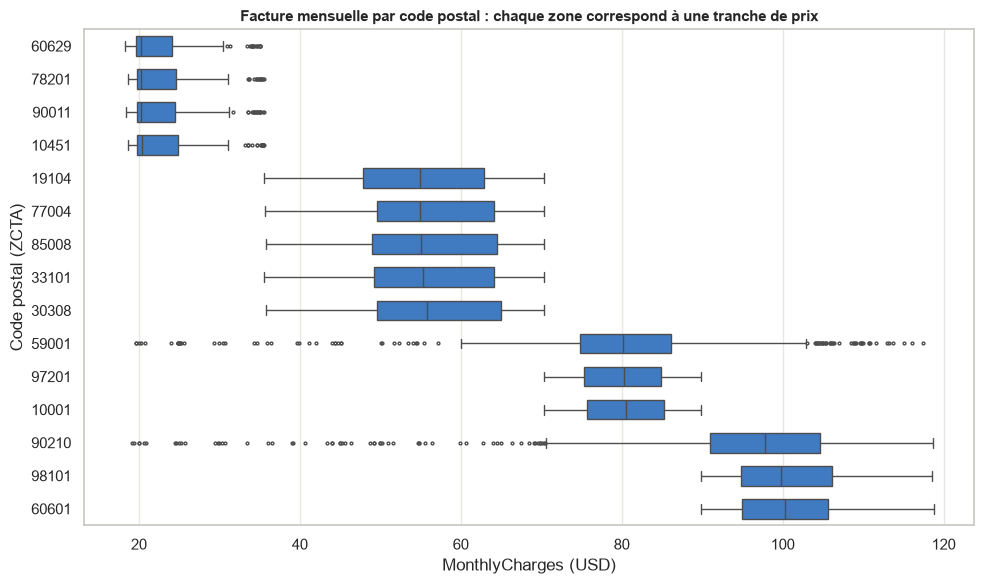

,min_charges,max_charges,part_seniors
zipcode,,,
60629,18.25,35.10,0.03
78201,18.70,35.50,0.04
90011,18.40,35.50,0.03
10451,18.70,35.50,0.02
19104,35.55,70.35,0.07
77004,35.65,70.35,0.09
85008,35.75,70.35,0.10
33101,35.55,70.35,0.05
30308,35.75,70.30,0.07


In [8]:
order = df_telco.groupby("zipcode")["MonthlyCharges"].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_telco,
    y="zipcode",
    x="MonthlyCharges",
    order=order,
    color=COLOR_STAY,
    width=0.6,
    fliersize=2,
    linewidth=1,
    ax=ax,
)
ax.set_title("Facture mensuelle par code postal : chaque zone correspond à une tranche de prix")
ax.set_xlabel("MonthlyCharges (USD)")
ax.set_ylabel("Code postal (ZCTA)")
plt.tight_layout()
plt.show()

df_telco.groupby("zipcode").agg(
    min_charges=("MonthlyCharges", "min"),
    max_charges=("MonthlyCharges", "max"),
    part_seniors=("SeniorCitizen", "mean"),
).loc[order].round(2)

Les codes postaux n'ont **pas été attribués indépendamment** des autres variables :
- 13 des 15 codes postaux correspondent à une **tranche de facture étanche** : < 35,5 $ · 35,5–70,4 $ · 70,4–89,9 $ · ≥ 89,9 $ ;
- les deux autres (**59001** et **90210**) couvrent toute la plage de prix et concentrent les seniors (≈ 40 %, contre 2 à 19 % ailleurs).

C'est cohérent avec la simulation décrite dans le notebook `2.0` (« MonthlyCharges → profil de richesse du zipcode, SeniorCitizen → biais zone rurale/retraitée »).

### 3.3 Churn par zone géographique

In [9]:
df_zip = (
    df_telco.assign(churn=(df_telco["Churn"] == "Yes").astype(int))
    .groupby("zipcode")
    .agg(nb_clients=("churn", "size"), taux_churn=("churn", "mean"), charges_moy=("MonthlyCharges", "mean"))
    .join(df_geo.set_index("zipcode")[["revenu_median", "age_median", "densite_population"]])
    .sort_values("taux_churn")
)
chi2_p = stats.chi2_contingency(pd.crosstab(df_telco["zipcode"], df_telco["Churn"]))[1]
zip_v = cramers_v(df_telco["zipcode"], df_telco["Churn"])
print(f"Test du chi² zipcode × churn : p = {chi2_p:.1e} · V de Cramér = {zip_v:.2f}")
print()
print("Corrélation de Spearman avec le taux de churn (niveau ZCTA, n = 15) :")
print(df_zip.drop(columns="nb_clients").corr("spearman")["taux_churn"].drop("taux_churn").round(2).to_string())
df_zip.round(3)

Test du chi² zipcode × churn : p = 1.1e-70 · V de Cramér = 0.23

Corrélation de Spearman avec le taux de churn (niveau ZCTA, n = 15) :
charges_moy           0.80
revenu_median         0.61
age_median            0.32
densite_population   -0.19


,nb_clients,taux_churn,charges_moy,revenu_median,age_median,densite_population
zipcode,,,,,,
78201,418,0.086,22.138,40356.0,37.7,2456.3
90011,438,0.105,22.167,51819.0,30.6,9546.1
60629,444,0.122,21.962,53318.0,32.9,5970.7
10451,425,0.125,22.384,34316.0,34.3,18757.2
30308,326,0.215,56.434,78429.0,31.4,5649.6
77004,394,0.223,55.795,68141.0,33.3,2615.7
33101,314,0.242,55.679,NaN,NaN,NaN
19104,334,0.246,55.214,33766.0,22.9,6771.5
85008,318,0.280,55.664,57728.0,30.4,2331.9


Le churn varie fortement d'un code postal à l'autre (8,6 % à 37,6 %), mais cet écart **suit d'abord la facture moyenne** de la zone (ρ = 0,80, contre 0,61 pour le revenu médian) : il reflète `MonthlyCharges`, déjà présent dans les données.
Ces corrélations portent sur 15 points seulement ; l'apport réel de la géographie est mesuré proprement en section 7.

## 4. Satisfaction et interactions support

### 4.1 Distributions

In [10]:
df = df_telco.merge(df_satisfaction, on="customerID", how="left")
df["churn_flag"] = (df["Churn"] == "Yes").astype(int)
df["statut"] = df["churn_flag"].map({0: "Fidèle", 1: "Churn"})

SAT_NUM = [
    "nb_appels_support",
    "duree_moy_appel_min",
    "score_satisfaction",
    "nps_score",
    "derniere_interaction_jours",
    "incident_facturation",
]
df_satisfaction[SAT_NUM].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
nb_appels_support,7043.0,3.03,2.06,0.0,1.0,3.0,4.0,10.0
duree_moy_appel_min,7043.0,11.92,7.20,0.0,7.0,11.0,16.0,37.0
score_satisfaction,7043.0,3.51,1.11,1.0,3.0,4.0,4.5,5.0
nps_score,7043.0,31.99,49.38,-100.0,-11.0,50.0,68.0,100.0
derniere_interaction_jours,7043.0,83.92,57.66,1.0,43.0,81.0,112.0,307.0
incident_facturation,7043.0,0.23,0.42,0.0,0.0,0.0,0.0,1.0


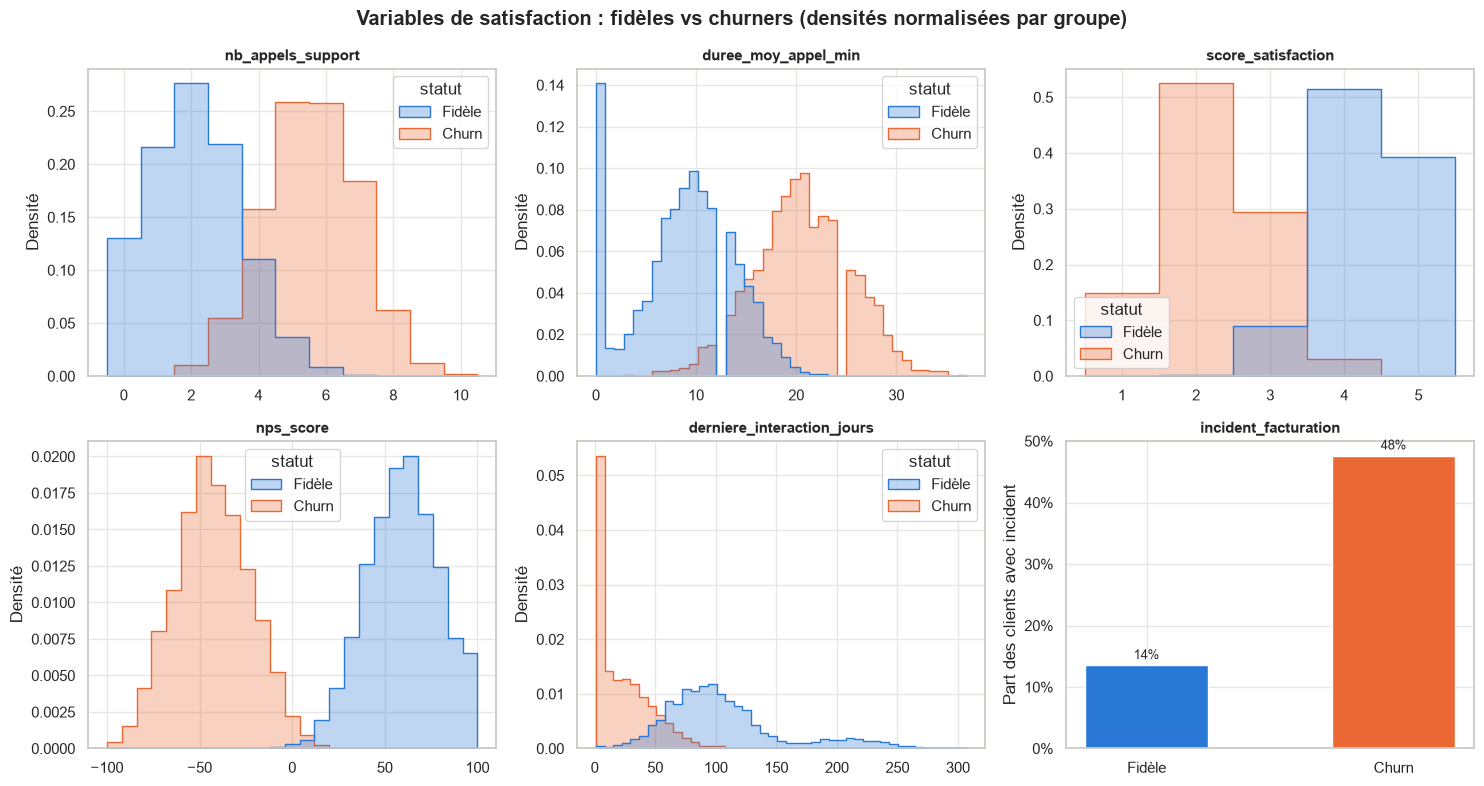

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, SAT_NUM, strict=True):
    if col == "incident_facturation":
        rate = df.groupby("statut")[col].mean().reindex(["Fidèle", "Churn"])
        ax.bar(rate.index, rate.values, color=[COLOR_STAY, COLOR_CHURN], width=0.5)
        for x, v in enumerate(rate.values):
            ax.text(x, v + 0.01, f"{v:.0%}", ha="center", fontsize=9)
        ax.set_ylabel("Part des clients avec incident")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    else:
        sns.histplot(
            data=df,
            x=col,
            hue="statut",
            hue_order=["Fidèle", "Churn"],
            palette=CHURN_PALETTE,
            stat="density",
            common_norm=False,
            element="step",
            fill=True,
            alpha=0.3,
            discrete=col in ("nb_appels_support", "score_satisfaction"),
            ax=ax,
        )
        ax.set_ylabel("Densité")
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Variables de satisfaction : fidèles vs churners (densités normalisées par groupe)", fontweight="bold")
plt.tight_layout()
plt.show()

Les distributions des deux groupes se recouvrent très peu, en particulier pour `nps_score` (quasiment disjointes autour de 0) et `score_satisfaction`. Ce niveau de séparation est inhabituel pour des données de satisfaction réelles.

### 4.2 Intensité du lien avec le churn

In [12]:
rows = []
for col in SAT_NUM:
    churn, stay = df.loc[df["churn_flag"] == 1, col], df.loc[df["churn_flag"] == 0, col]
    rows.append(
        {
            "variable": col,
            "moyenne fidèles": stay.mean(),
            "moyenne churners": churn.mean(),
            "ρ Spearman avec churn": stats.spearmanr(df[col], df["churn_flag"])[0],
            "p-value Mann-Whitney": stats.mannwhitneyu(churn, stay).pvalue,
        }
    )
display(pd.DataFrame(rows).set_index("variable").round(3))

# Point de comparaison : les variables Telco les plus liées au churn
print(f"Référence Telco — tenure   : ρ = {stats.spearmanr(df['tenure'], df['churn_flag'])[0]:.2f}")
print(f"Référence Telco — Contract : V de Cramér = {cramers_v(df['Contract'], df['Churn']):.2f}")
print(f"motif_contact_principal    : V de Cramér = {cramers_v(df['motif_contact_principal'], df['Churn']):.2f}")

,moyenne fidèles,moyenne churners,ρ Spearman avec churn,p-value Mann-Whitney
variable,,,,
nb_appels_support,2.116,5.569,0.703,0.0
duree_moy_appel_min,8.795,20.569,0.701,0.0
score_satisfaction,4.061,1.971,-0.753,0.0
nps_score,59.188,-43.298,-0.765,0.0
derniere_interaction_jours,106.062,22.636,-0.710,0.0
incident_facturation,0.135,0.476,0.360,0.0


Référence Telco — tenure   : ρ = -0.37
Référence Telco — Contract : V de Cramér = 0.41
motif_contact_principal    : V de Cramér = 0.80


Cinq variables atteignent |ρ| ≈ 0,70–0,77, soit **deux fois plus** que les meilleures variables Telco (`tenure` ρ = −0,37 ; `Contract` V = 0,41). Le motif de contact (V = 0,80) est lui aussi deux fois plus associé au churn que `Contract`.

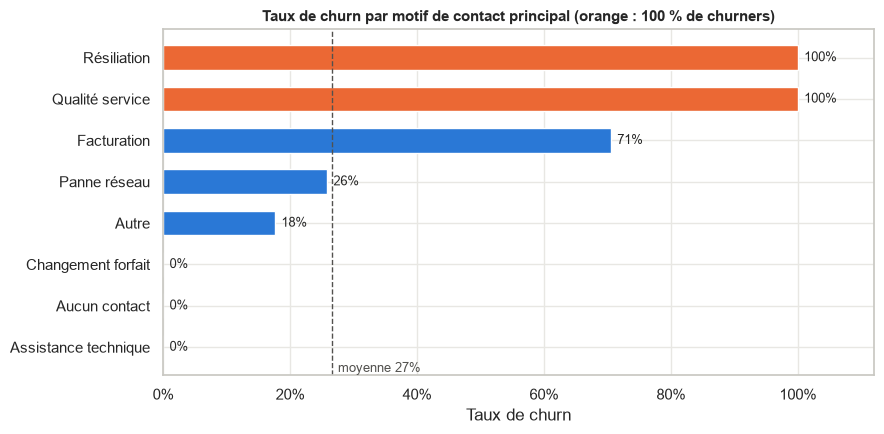

,taux_churn,nb_clients
motif_contact_principal,,
Assistance technique,0.000,1603
Aucun contact,0.000,674
Changement forfait,0.000,1119
Autre,0.176,811
Panne réseau,0.258,1193
Facturation,0.705,764
Qualité service,1.000,221
Résiliation,1.000,658


In [13]:
motifs = (
    df.groupby("motif_contact_principal")["churn_flag"]
    .agg(taux_churn="mean", nb_clients="size")
    .sort_values("taux_churn")
)
churn_rate = df["churn_flag"].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(
    motifs.index,
    motifs["taux_churn"],
    color=[COLOR_CHURN if v == 1 else COLOR_STAY for v in motifs["taux_churn"]],
    height=0.6,
)
ax.axvline(churn_rate, color=COLOR_MUTED, linestyle="--", linewidth=1)
ax.text(churn_rate + 0.01, -0.6, f"moyenne {churn_rate:.0%}", color=COLOR_MUTED, fontsize=9)
for y_pos, v in enumerate(motifs["taux_churn"]):
    ax.text(v + 0.01, y_pos, f"{v:.0%}", va="center", fontsize=9)
ax.set_xlim(0, 1.12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Taux de churn par motif de contact principal (orange : 100 % de churners)")
ax.set_xlabel("Taux de churn")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
motifs.round(3)

Trois motifs ne contiennent **aucun** churner, deux ne contiennent **que** des churners. Le motif « Résiliation » est par ailleurs une **conséquence** du départ, pas un signal qui le précède.

### 4.3 Test de fuite de la cible

Si une variable « contient » la réponse, une règle d'une ligne suffit à prédire le churn. On compare quelques règles simples à la référence naïve (« personne ne churne »). Les seuils sont lus sur les distributions de la section 4.1 (zone de croisement des deux groupes).

In [14]:
y = df["churn_flag"]
rules = {
    "Référence : personne ne churne": pd.Series(False, index=df.index),
    "nps_score <= 0": df["nps_score"] <= 0,
    "score_satisfaction < 3": df["score_satisfaction"] < 3,
    "derniere_interaction_jours < 40": df["derniere_interaction_jours"] < 40,
    "motif ∈ {Résiliation, Qualité service}": df["motif_contact_principal"].isin(["Résiliation", "Qualité service"]),
}
pd.DataFrame({name: evaluate_rule(pred, y) for name, pred in rules.items()}).T.round(3)

,accuracy,précision,rappel
Référence : personne ne churne,0.735,NaN,0.000
nps_score <= 0,0.994,0.994,0.986
score_satisfaction < 3,0.958,0.948,0.889
derniere_interaction_jours < 40,0.914,0.885,0.775
"motif ∈ {Résiliation, Qualité service}",0.859,1.000,0.470


**Fuite de cible confirmée** : la règle `nps_score <= 0` prédit le churn avec **99,4 %** d'accuracy (précision 99,4 %, rappel 98,6 %), sans aucun modèle.
Les données de satisfaction ont manifestement été **générées conditionnellement à `Churn`**. Deux conséquences :
- **statistique** : tout modèle entraîné dessus afficherait des performances artificielles, sans valeur en production ;
- **métier / temporelle** : certaines variables décrivent le départ lui-même (motif « Résiliation », interaction très récente) et ne seraient pas disponibles au moment où l'on veut anticiper le churn.

## 5. Verbatims clients (feedback)

### 5.1 Couverture

In [15]:
df = df.merge(
    df_feedback[["customerID", "CustomerFeedback", "feedback_length", "sentiment", "HasFeedback"]],
    on="customerID",
    how="left",
)
# Les 11 clients tenure = 0 sont absents du fichier feedback : pas de verbatim
df["HasFeedback"] = df["HasFeedback"].eq(True)
# Sans verbatim, le sentiment vaut 0.0 dans la source : c'est une absence d'avis, pas un avis neutre
df.loc[~df["HasFeedback"], "sentiment"] = np.nan

coverage_p = stats.chi2_contingency(pd.crosstab(df["HasFeedback"], df["Churn"]))[1]
print(f"Test du chi² présence de feedback × churn : p = {coverage_p:.2f}")
pd.crosstab(df["HasFeedback"], df["statut"], normalize="columns").round(3)

Test du chi² présence de feedback × churn : p = 0.95


statut,Churn,Fidèle
HasFeedback,,
False,0.75,0.751
True,0.25,0.249


25 % des clients ont un verbatim, **dans les mêmes proportions chez les fidèles et les churners** (chi² non significatif) : la présence d'un feedback est indépendante du churn et ne constitue pas un signal en soi.

### 5.2 Sentiment

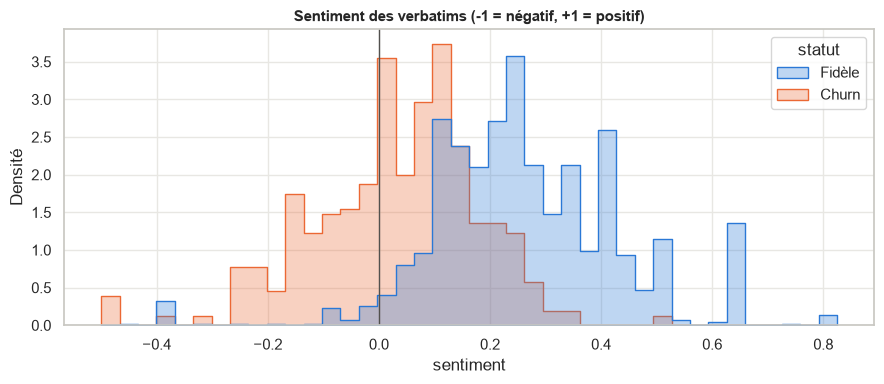

Test de Mann-Whitney sentiment churners vs fidèles : p = 2.4e-122


,count,mean,std,min,25%,50%,75%,max
statut,,,,,,,,
Churn,468.0,0.029,0.151,-0.50,-0.061,0.049,0.126,0.500
Fidèle,1290.0,0.263,0.175,-0.45,0.150,0.242,0.370,0.825


In [16]:
fb_only = df[df["HasFeedback"]]

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(
    data=fb_only,
    x="sentiment",
    hue="statut",
    hue_order=["Fidèle", "Churn"],
    palette=CHURN_PALETTE,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.3,
    bins=40,
    ax=ax,
)
ax.axvline(0, color=COLOR_MUTED, linewidth=1)
ax.set_title("Sentiment des verbatims (-1 = négatif, +1 = positif)")
ax.set_xlabel("sentiment")
ax.set_ylabel("Densité")
plt.tight_layout()
plt.show()

sentiment_p = stats.mannwhitneyu(
    fb_only.loc[fb_only["churn_flag"] == 1, "sentiment"], fb_only.loc[fb_only["churn_flag"] == 0, "sentiment"]
).pvalue
print(f"Test de Mann-Whitney sentiment churners vs fidèles : p = {sentiment_p:.1e}")
fb_only.groupby("statut")["sentiment"].describe().round(3)

Le sentiment médian des churners (0,05) est nettement inférieur à celui des fidèles (0,24). L'écart est attendu, mais il faut vérifier **comment** les verbatims ont été produits.

### 5.3 Origine des verbatims

In [17]:
print("Prompt envoyé au LLM pour générer le verbatim du premier client :\n")
print(df_feedback_raw.loc[0, "PromptInput"])

Prompt envoyé au LLM pour générer le verbatim du premier client :

Write a realistic customer feedback based on this profile:
Churn: No
Tenure: 1 months
Contract type: Month-to-month
Monthly Charges: $29.85
Internet Service: DSL
Payment Method: Electronic check


In [18]:
# Heuristique par mots-clés : mesure indicative de la part de verbatims qui évoquent un départ
CHURN_KEYWORDS = r"cancel|switch|leav|terminat|discontinu|churn|moving to another"

mentions = fb_only["CustomerFeedback"].str.lower().str.contains(CHURN_KEYWORDS)
print(f"Verbatims évoquant un départ — churners : {mentions[fb_only['churn_flag'] == 1].mean():.1%}")
print(f"Verbatims évoquant un départ — fidèles  : {mentions[fb_only['churn_flag'] == 0].mean():.1%}")

Verbatims évoquant un départ — churners : 96.8%
Verbatims évoquant un départ — fidèles  : 31.6%


Le prompt de génération contient **explicitement la cible** (`Churn: Yes/No`). Le LLM a donc rédigé des avis de départ pour les churners : **97 % de leurs verbatims évoquent un départ** (contre 32 % chez les fidèles, souvent sous forme négative : « *I would not consider switching* »).
Le texte et le sentiment qui en découle constituent donc eux aussi une **fuite de cible**. Ces données restent utiles pour démontrer la chaîne NLP (stockage MongoDB, scoring de sentiment), mais pas pour mesurer la performance du modèle.

## 6. Jeu de données consolidé

In [19]:
df_enriched = df.drop(columns="statut").merge(
    df_geo[["zipcode", "revenu_median", "age_median", "densite_population"]],
    on="zipcode",
    how="left",
)
df_enriched["TotalCharges"] = pd.to_numeric(df_enriched["TotalCharges"], errors="coerce")
assert df_enriched["customerID"].is_unique and len(df_enriched) == len(df_telco)

ENRICHED_PATH = DATA_PROCESSED / "telco_enriched_exploration.csv"
df_enriched.to_csv(ENRICHED_PATH, index=False)
n_rows, n_cols = df_enriched.shape
print(f"{n_rows} lignes × {n_cols} colonnes → {ENRICHED_PATH.relative_to(PROJECT_ROOT).as_posix()}")

7043 lignes × 37 colonnes → data/processed/telco_enriched_exploration.csv


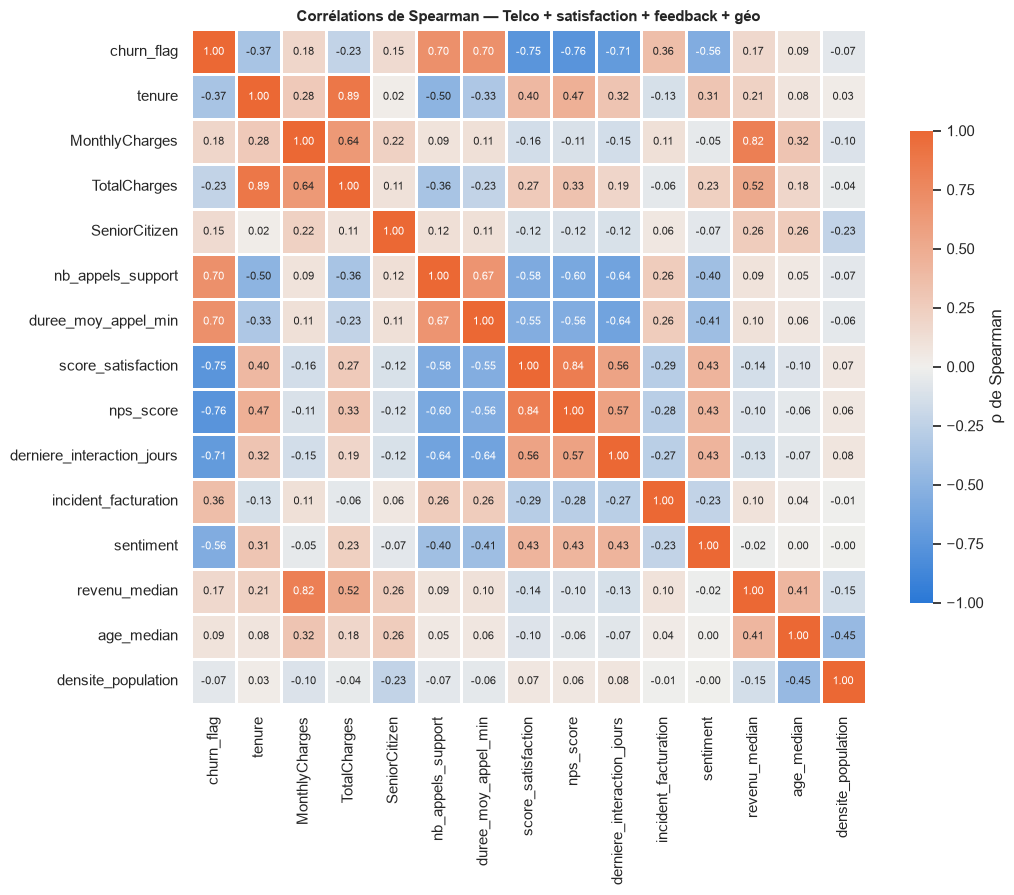

In [20]:
CORR_COLS = [
    "churn_flag",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    *SAT_NUM,
    "sentiment",
    "revenu_median",
    "age_median",
    "densite_population",
]
corr = df_enriched[CORR_COLS].corr("spearman")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    cmap=DIVERGING_CMAP,
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=2,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.7, "label": "ρ de Spearman"},
    ax=ax,
)
ax.set_title("Corrélations de Spearman — Telco + satisfaction + feedback + géo")
plt.tight_layout()
plt.show()

La matrice résume les constats : la **satisfaction** et le **sentiment** sont bien plus corrélés au churn que les variables Telco ; le **revenu médian** suit `MonthlyCharges` (ρ = 0,82).

> `data/processed/telco_enriched_exploration.csv` est un **artefact d'exploration** (non versionné). La construction officielle du jeu enrichi relève du pipeline Bronze → Silver → Gold (P4).

## 7. Mesure de l'impact : étude d'ablation

Les corrélations ne disent pas ce que chaque source **apporte à un modèle**. On entraîne donc le même modèle simple avec différents jeux de variables et on compare la ROC-AUC en validation croisée.

- **Modèle** : régression logistique (imputation médiane + standardisation, encodage one-hot). Le but est de comparer des jeux de variables, pas d'optimiser un modèle.
- **Protocole** : validation croisée stratifiée à 5 plis, graine fixe, mêmes plis pour toutes les configurations.
- **Périmètre** : 7 032 clients (hors 11 clients `tenure = 0`). Le sentiment n'existant que pour 25 % des clients, il est comparé à la référence Telco **sur ce même sous-ensemble**.

In [21]:
TELCO_NUM = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
TELCO_CAT = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]
GEO_NUM = ["revenu_median", "age_median", "densite_population"]
SAT_CAT = ["motif_contact_principal"]

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def build_model(num_cols: list[str], cat_cols: list[str]):
    preprocessing = ColumnTransformer(
        [
            ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    )
    return make_pipeline(preprocessing, LogisticRegression(max_iter=2000))


def cv_auc(data: pd.DataFrame, num_cols: list[str], cat_cols: list[str]) -> np.ndarray:
    return cross_val_score(
        build_model(num_cols, cat_cols), data[num_cols + cat_cols], data["churn_flag"], cv=CV, scoring="roc_auc"
    )


model_data = df_enriched.dropna(subset=["TotalCharges"]).reset_index(drop=True)
fb_data = model_data[model_data["HasFeedback"]].reset_index(drop=True)

experiments = [
    # (configuration, périmètre, variables numériques, variables catégorielles, statut)
    ("Telco (référence)", "tous les clients", model_data, TELCO_NUM, TELCO_CAT, "référence"),
    ("Telco + géo", "tous les clients", model_data, TELCO_NUM + GEO_NUM, TELCO_CAT, "redondant"),
    ("Telco + satisfaction", "tous les clients", model_data, TELCO_NUM + SAT_NUM, TELCO_CAT + SAT_CAT, "fuite"),
    ("Satisfaction seule", "tous les clients", model_data, SAT_NUM, SAT_CAT, "fuite"),
    ("Telco (référence)", "clients avec feedback", fb_data, TELCO_NUM, TELCO_CAT, "référence"),
    ("Telco + sentiment", "clients avec feedback", fb_data, TELCO_NUM + ["sentiment"], TELCO_CAT, "fuite"),
]

results = []
for name, scope, data, num_cols, cat_cols, status in experiments:
    scores = cv_auc(data, num_cols, cat_cols)
    results.append(
        {
            "configuration": name,
            "périmètre": scope,
            "n clients": len(data),
            "nb variables": len(num_cols + cat_cols),
            "ROC-AUC moyenne": scores.mean(),
            "écart-type": scores.std(),
            "statut": status,
        }
    )
df_results = pd.DataFrame(results)
df_results.round(3)

,configuration,périmètre,n clients,nb variables,ROC-AUC moyenne,écart-type,statut
0,Telco (référence),tous les clients,7032,19,0.845,0.003,référence
1,Telco + géo,tous les clients,7032,22,0.845,0.003,redondant
2,Telco + satisfaction,tous les clients,7032,26,1.000,0.000,fuite
3,Satisfaction seule,tous les clients,7032,7,1.000,0.000,fuite
4,Telco (référence),clients avec feedback,1758,19,0.832,0.018,référence
5,Telco + sentiment,clients avec feedback,1758,20,0.926,0.004,fuite


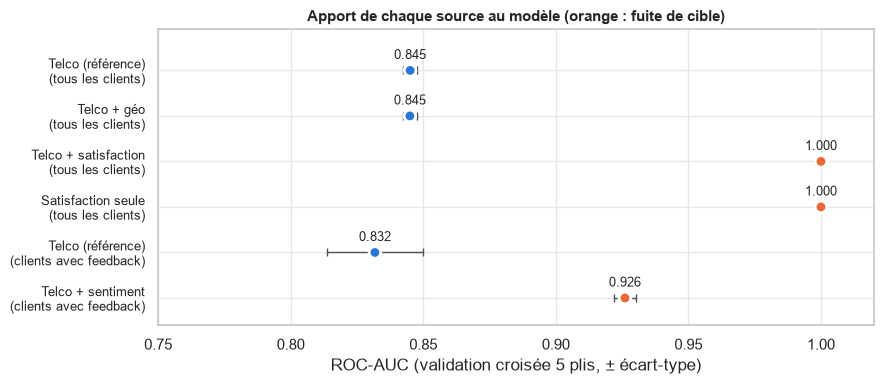

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = df_results["configuration"] + "\n(" + df_results["périmètre"] + ")"
colors = [COLOR_CHURN if s == "fuite" else COLOR_STAY for s in df_results["statut"]]
y_pos = np.arange(len(df_results))[::-1]
ax.errorbar(
    df_results["ROC-AUC moyenne"],
    y_pos,
    xerr=df_results["écart-type"],
    fmt="none",
    ecolor=COLOR_MUTED,
    elinewidth=1,
    capsize=3,
)
ax.scatter(df_results["ROC-AUC moyenne"], y_pos, c=colors, s=70, zorder=3, edgecolors="white", linewidths=2)
for yp, v in zip(y_pos, df_results["ROC-AUC moyenne"], strict=True):
    ax.text(v, yp + 0.25, f"{v:.3f}", ha="center", fontsize=9)
ax.set_yticks(y_pos, labels, fontsize=9)
ax.set_xlim(0.75, 1.02)
ax.set_ylim(-0.6, len(df_results) - 0.1)
ax.set_xlabel("ROC-AUC (validation croisée 5 plis, ± écart-type)")
ax.set_title("Apport de chaque source au modèle (orange : fuite de cible)")
plt.tight_layout()
plt.show()

- **Géographie** : ROC-AUC identique à la référence au millième près (0,845). Les variables Census n'apportent **aucune information** que `MonthlyCharges` et `SeniorCitizen` ne contiennent déjà.
- **Satisfaction** : ROC-AUC de **1,00**, et 1,00 également **sans aucune variable Telco**. Un score parfait sur un problème de churn réel n'est pas crédible : c'est la signature d'une fuite de cible.
- **Sentiment** : à lui seul, il fait passer la ROC-AUC de 0,832 à 0,926 sur les clients avec feedback, un gain qui vient du prompt contenant la cible.

La référence **Telco seule (0,845)** est donc la seule performance honnête à ce stade : c'est la **baseline** à battre en P5.

## 8. Synthèse et recommandations

### Constats

| Source | Constat | Exploitable pour le modèle ? |
|---|---|---|
| `telco.csv` | Saine ; 11 clients `tenure = 0` à `TotalCharges` vide | ✅ Oui : baseline ROC-AUC 0,845 |
| Satisfaction | Générée conditionnellement à `Churn` ; `nps_score <= 0` → 99,4 % d'accuracy ; ROC-AUC 1,00 | ❌ Non en l'état (fuite de cible) |
| Feedback | Prompt LLM contenant `Churn: Yes/No` ; 97 % des verbatims de churners évoquent un départ ; couverture 25 %, indépendante du churn | ❌ Non pour le score · ✅ oui pour la démo NLP / MongoDB |
| Géo (Census) | Codes postaux attribués d'après `MonthlyCharges` / `SeniorCitizen` ; 15 ZCTA dont 33101 sans données (314 clients) ; ROC-AUC inchangée | ⚠️ Redondant |

### Règles de nettoyage pour la couche Silver
1. Supprimer (ou isoler) les 11 clients `tenure = 0` dont `TotalCharges` est vide.
2. Harmoniser les conventions entre sources : `customerID` en majuscules, casse des catégories, `Churn` en booléen.
3. Supprimer les colonnes d'index exportées (`Unnamed: 0`) des fichiers `*_prep.csv`.
4. `sentiment = NULL` lorsque `HasFeedback = False` (et non `0.0`, qui signifierait « neutre »).
5. Census : remplacer la sentinelle `-666666666` par `NULL` ; densité `NULL` pour un ZCTA sans habitants.

### Décisions à prendre en binôme / avec Vincent
1. **Satisfaction** : régénérer les données sans dépendance déterministe au churn (SDV entraîné sans la cible, ou génération conditionnelle **bruitée**) et exclure les variables postérieures au départ (`motif = Résiliation`, `derniere_interaction_jours`).
2. **Feedback** : régénérer les verbatims avec un prompt **sans la cible** (profil client uniquement), ou les réserver explicitement à la démonstration NLP.
3. **Géo** : réattribuer les codes postaux indépendamment de la facture (par exemple tirage pondéré par la population), élargir au-delà de 15 ZCTA et remplacer 33101 par un ZCTA résidentiel.
4. **Modélisation (P5)** : retenir la baseline Telco (ROC-AUC 0,845) et rejouer cette étude d'ablation à chaque nouvelle source enrichie.

### Limites de l'analyse
- Toutes les sources d'enrichissement sont **synthétiques** : les constats portent sur la manière dont elles ont été générées, pas sur le comportement de vrais clients.
- La détection des verbatims « de départ » repose sur une **heuristique par mots-clés** (indicative, non validée manuellement).
- L'étude d'ablation utilise un modèle linéaire volontairement simple : les écarts relatifs entre configurations comptent plus que les valeurs absolues.
- La méthode de calcul du `sentiment` n'est pas documentée.